In [61]:
# 1. Setup and imports

import os
import warnings
import shap
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    RandomizedSearchCV, cross_validate
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, precision_score,
    recall_score, balanced_accuracy_score, matthews_corrcoef,
    confusion_matrix, classification_report, brier_score_loss,
    roc_curve, precision_recall_curve
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import cross_val_predict
from sklearn.base import clone
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import kagglehub

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded.")

Libraries loaded.


In [62]:
# 2.1 Load data

path = "/kaggle/input/datasets/shivamb/machine-predictive-maintenance-classification/predictive_maintenance.csv"
df = pd.read_csv(path)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
display(df.head())

Shape: (10000, 10)

Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Failure Type']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [63]:
# 2.2 Basic info, missing values, duplicates

print("Data types:")
display(df.dtypes)

print("\n\nMissing values:")
display(df.isna().sum())

print("\n\nDuplicate rows:", df.duplicated().sum())

print("\n\nTarget distribution:")
display(df["Target"].value_counts())
display(df["Target"].value_counts(normalize=True).rename("ratio"))

print("\n\nFailure Type distribution:")
display(df["Failure Type"].value_counts())
display(df["Failure Type"].value_counts(normalize=True).rename("ratio"))

print("\n\nType distribution:")
display(df["Type"].value_counts())

Data types:


UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
Failure Type                object
dtype: object



Missing values:


UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64



Duplicate rows: 0


Target distribution:


...



Failure Type distribution:


Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

Failure Type
No Failure                  0.9652
Heat Dissipation Failure    0.0112
Power Failure               0.0095
Overstrain Failure          0.0078
Tool Wear Failure           0.0045
Random Failures             0.0018
Name: ratio, dtype: float64



Type distribution:


Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [64]:
# 2.3 Summary statistics

display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UDI,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Product ID,10000,10000,L57163,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Target,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
Failure Type,10000,6,No Failure,9652,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
# 2.4 Data inconsistencies

inconsistent = df[
    ((df["Target"] == 1) & (df["Failure Type"] == "No Failure")) |
    ((df["Target"] == 0) & (df["Failure Type"] != "No Failure"))
].copy()

print("Number of inconsistent rows:", len(inconsistent))
display(inconsistent[["UDI", "Target", "Failure Type"]].head(20))
print(inconsistent["Target"].value_counts())

Number of inconsistent rows: 27


,UDI,Target,Failure Type
1221,1222,0,Random Failures
1302,1303,0,Random Failures
1437,1438,1,No Failure
1748,1749,0,Random Failures
2072,2073,0,Random Failures
2559,2560,0,Random Failures
2749,2750,1,No Failure
3065,3066,0,Random Failures
3452,3453,0,Random Failures
4044,4045,1,No Failure


Target
0    18
1     9
Name: count, dtype: int64


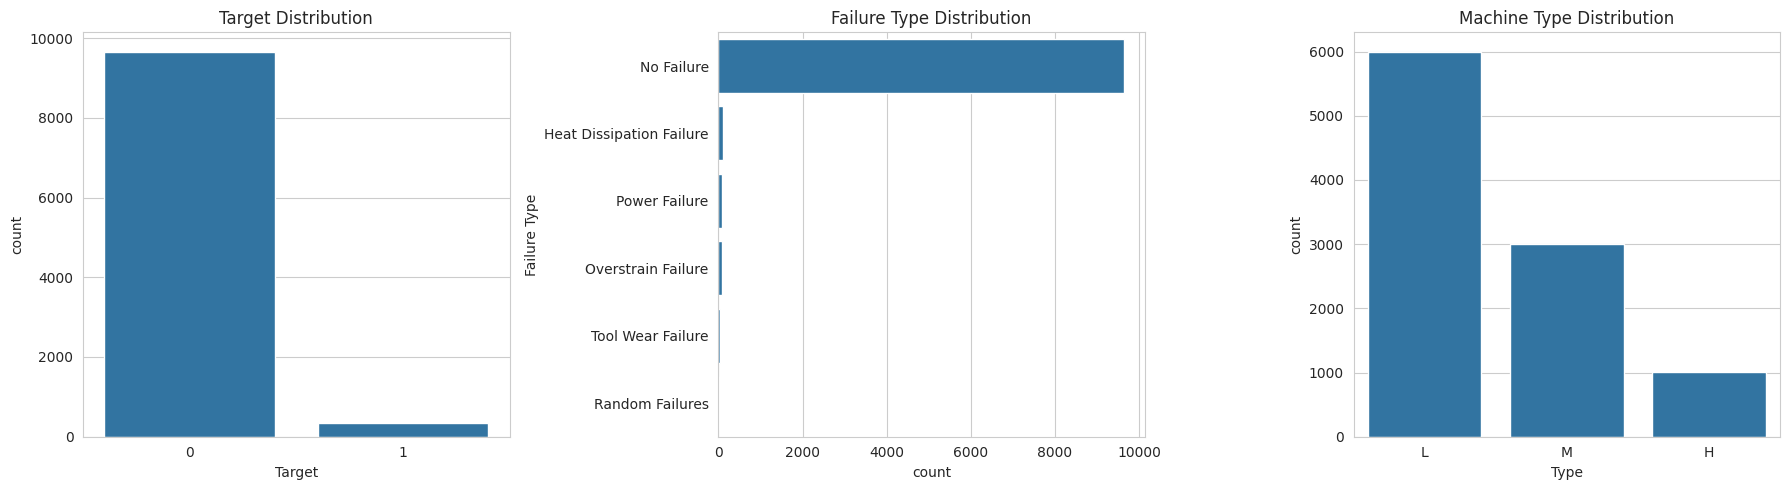

In [66]:
# 2.5 Target, Failure Type, Type plots

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="Target", ax=axes[0])
axes[0].set_title("Target Distribution")

sns.countplot(data=df, y="Failure Type", order=df["Failure Type"].value_counts().index, ax=axes[1])
axes[1].set_title("Failure Type Distribution")

sns.countplot(data=df, x="Type", order=["L", "M", "H"], ax=axes[2])
axes[2].set_title("Machine Type Distribution")

plt.tight_layout()
plt.show()

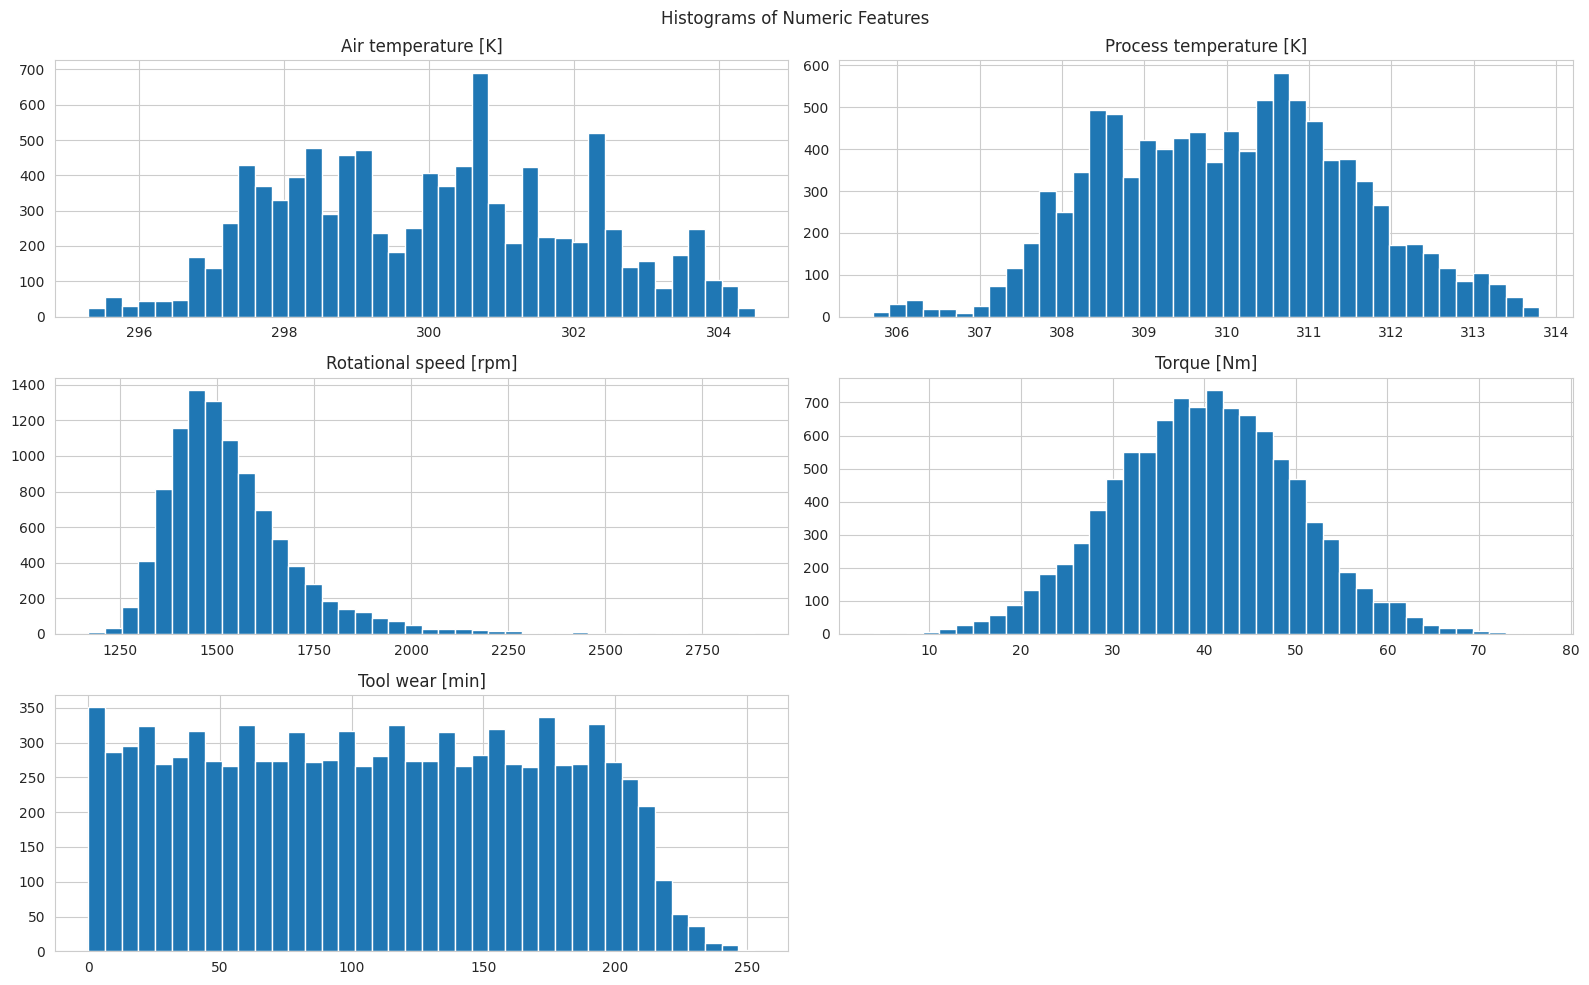

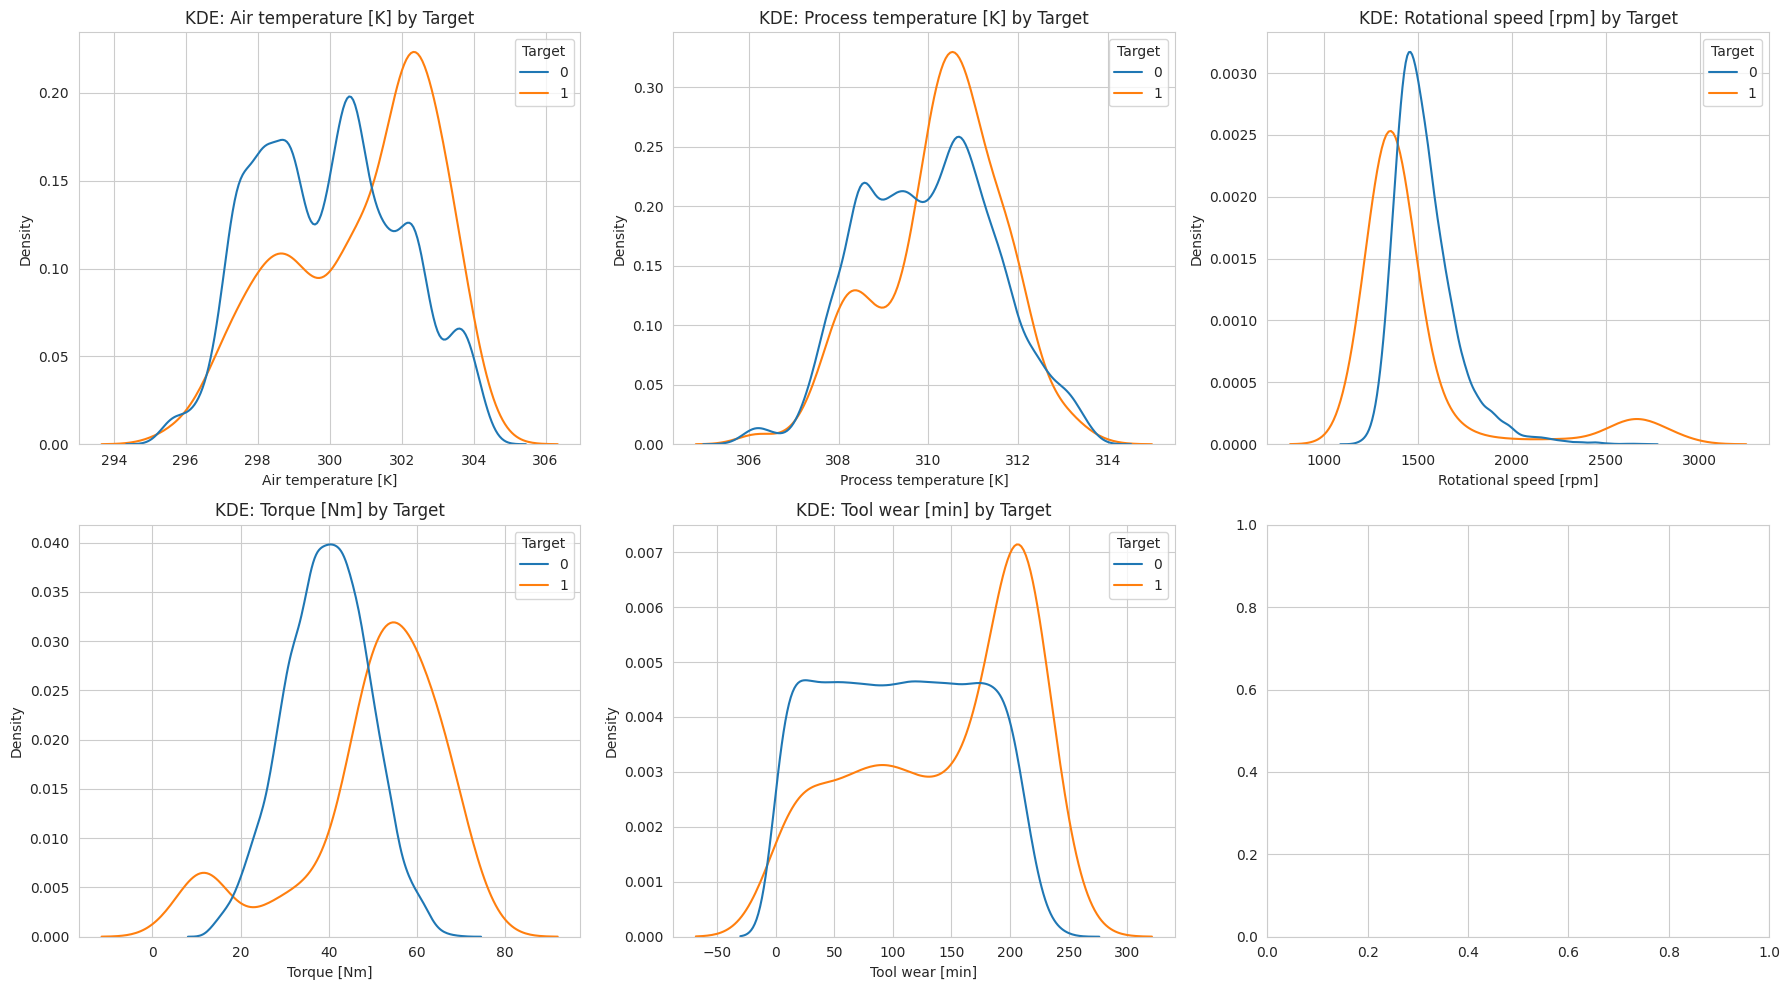

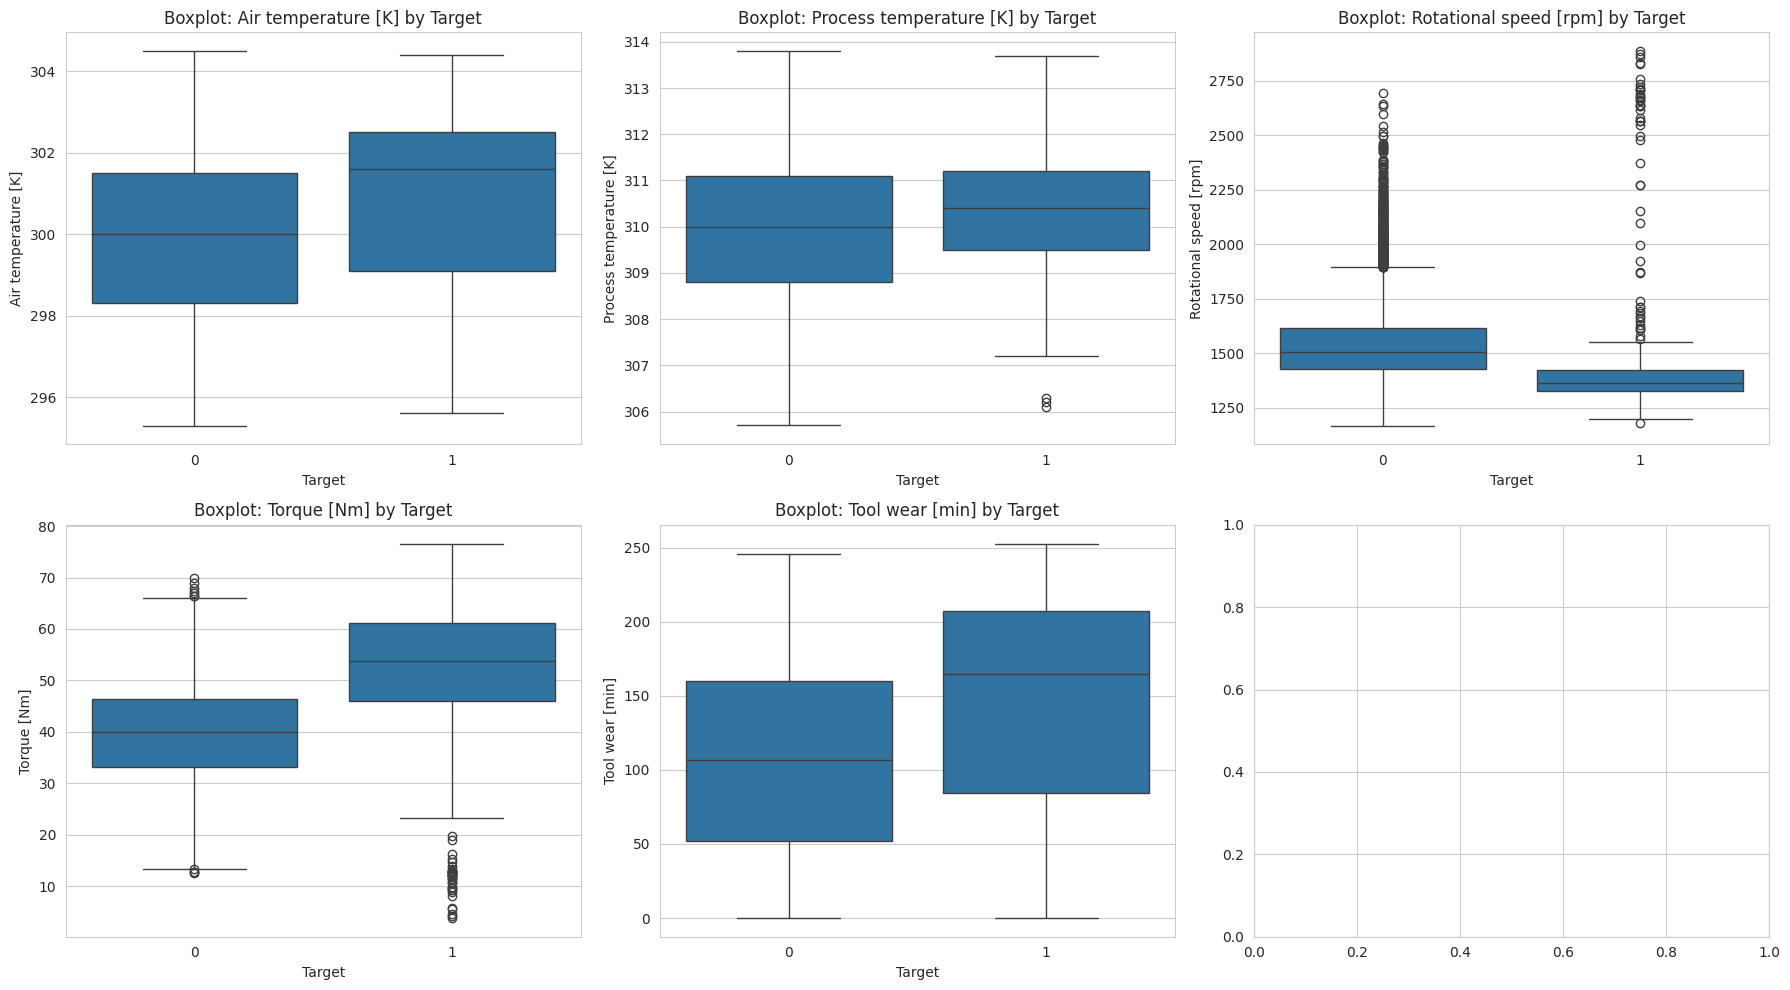

In [67]:
# 2.6 Numeric feature distributions

num_cols = [
    "Air temperature [K]", "Process temperature [K]",
    "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"
]

df[num_cols].hist(bins=40, figsize=(16, 10))
plt.suptitle("Histograms of Numeric Features")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue="Target", common_norm=False, ax=axes[i])
    axes[i].set_title(f"KDE: {col} by Target")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x="Target", y=col, ax=axes[i])
    axes[i].set_title(f"Boxplot: {col} by Target")
plt.tight_layout()
plt.show()

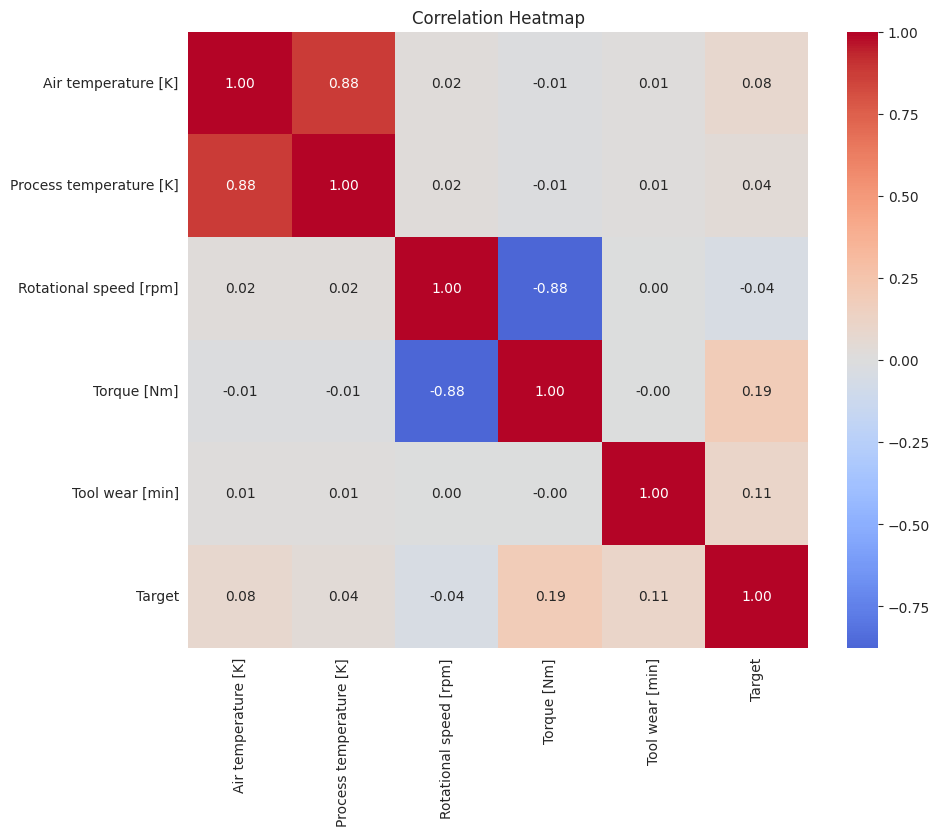

In [68]:
# 2.7 Correlation heatmap

plt.figure(figsize=(10, 8))
corr = df[num_cols + ["Target"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

,mean,count
Type,,
L,0.039167,6000
M,0.027694,2997
H,0.020937,1003


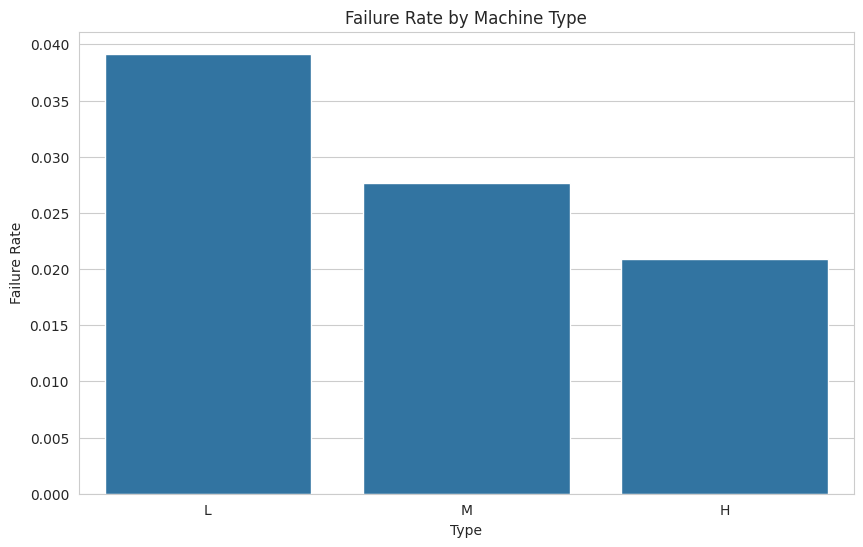

In [69]:
# 2.8 Failure rate by Type

type_fail = df.groupby("Type")["Target"].agg(["mean", "count"]).sort_values("mean", ascending=False)
display(type_fail)

sns.barplot(data=type_fail.reset_index(), x="Type", y="mean", order=["L", "M", "H"])
plt.title("Failure Rate by Machine Type")
plt.ylabel("Failure Rate")
plt.show()

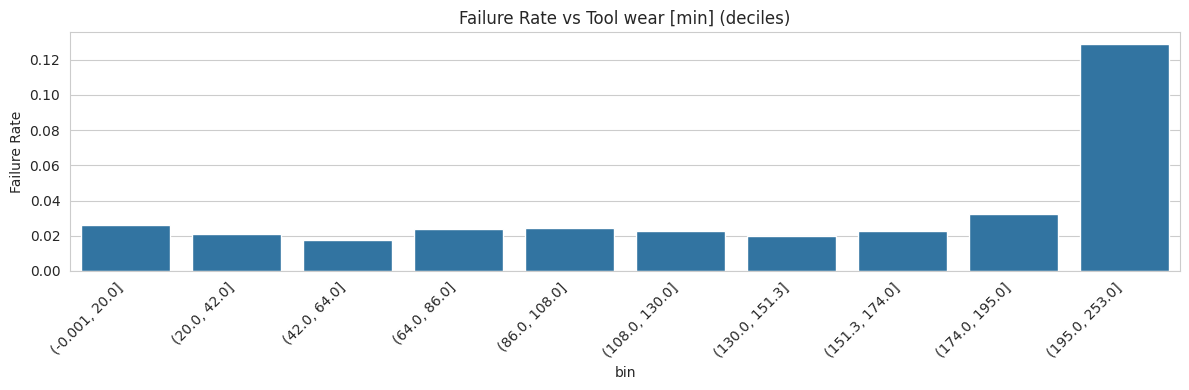

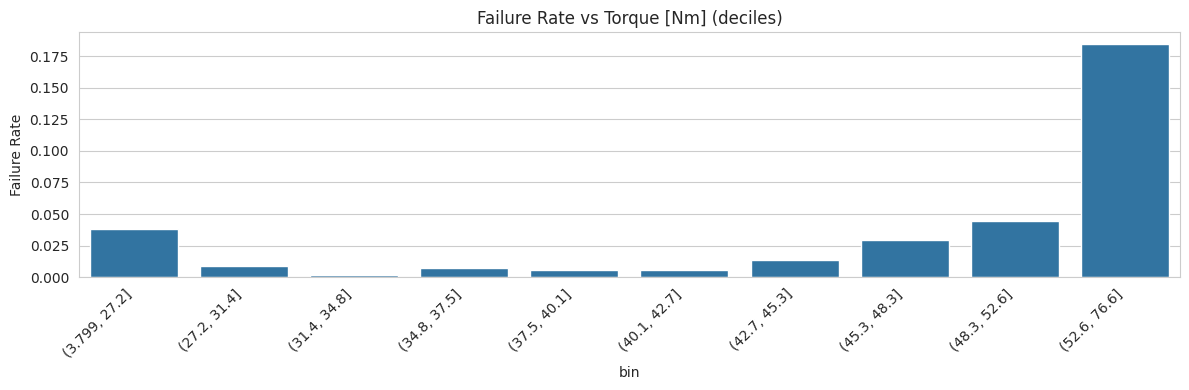

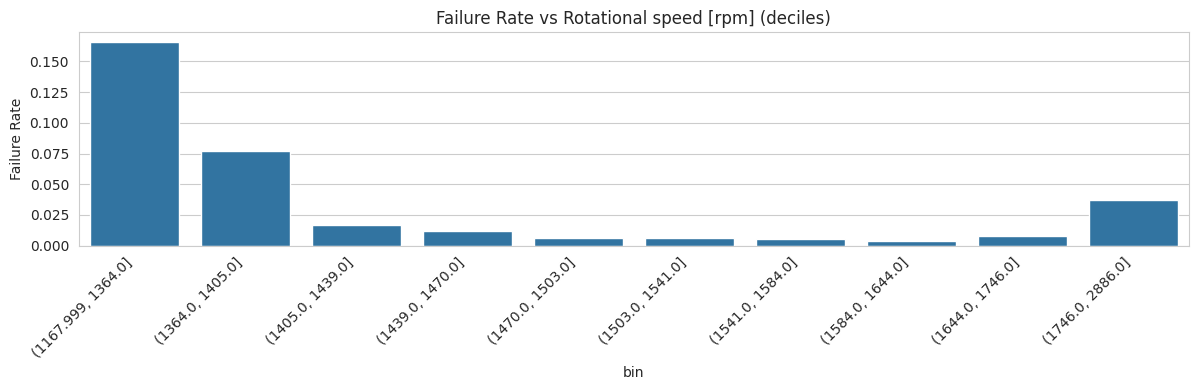

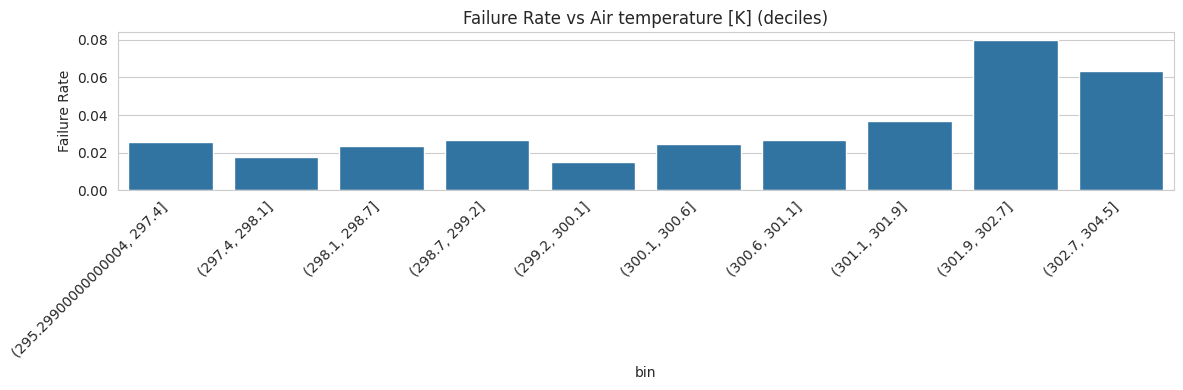

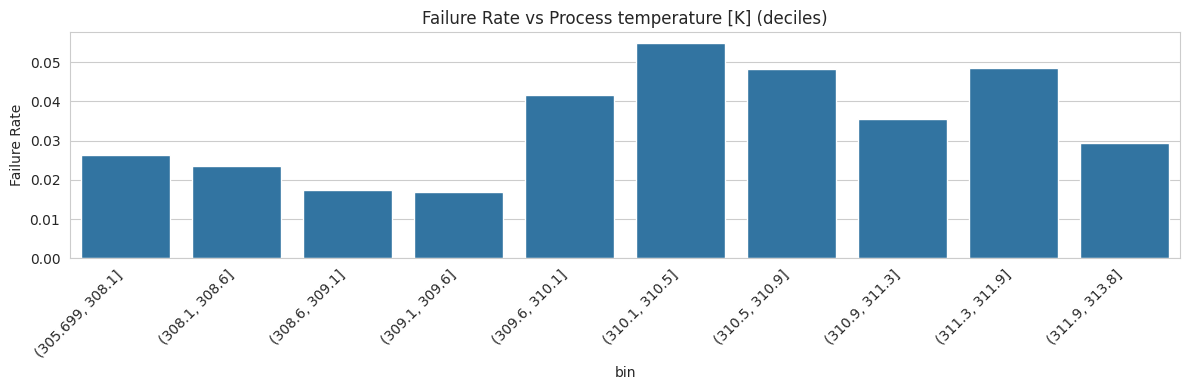

In [70]:
# 2.9 Failure rate vs binned numeric features

def failure_rate_by_bin(df, col, bins=10):
    tmp = df.copy()
    tmp["bin"] = pd.qcut(tmp[col], q=bins, duplicates="drop")
    return tmp.groupby("bin")["Target"].agg(["mean", "count"]).reset_index()

for col in ["Tool wear [min]", "Torque [Nm]", "Rotational speed [rpm]",
            "Air temperature [K]", "Process temperature [K]"]:
    res = failure_rate_by_bin(df, col)
    plt.figure(figsize=(12, 4))
    sns.barplot(data=res, x="bin", y="mean")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Failure Rate vs {col} (deciles)")
    plt.ylabel("Failure Rate")
    plt.tight_layout()
    plt.show()

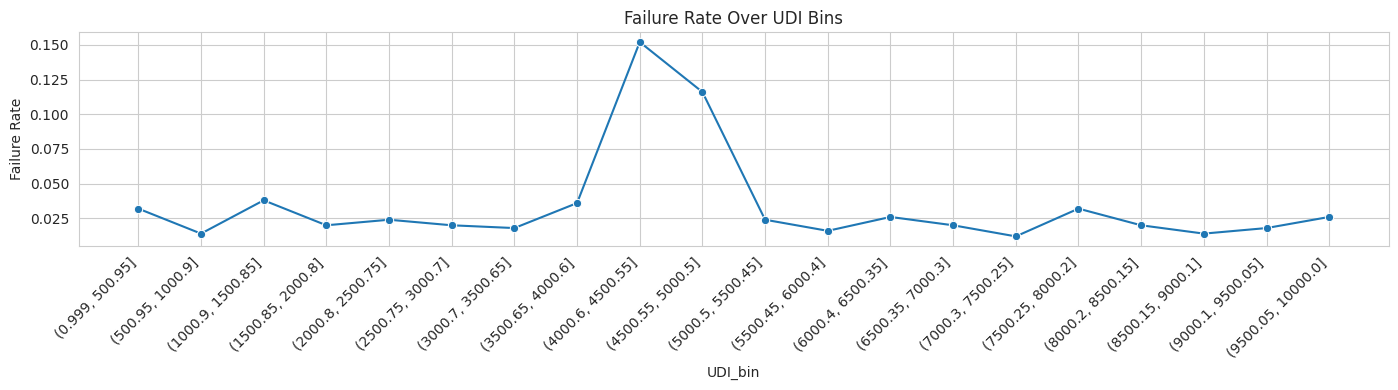

In [71]:
# 2.10 Temporal pattern by UDI

df_sorted = df.sort_values("UDI").copy()

# Create bins and convert the categorical intervals to string labels
df_sorted["UDI_bin"] = pd.qcut(df_sorted["UDI"], q=20, duplicates="drop")

# Convert the categorical interval to its string representation
df_sorted["UDI_bin"] = df_sorted["UDI_bin"].astype(str)

temporal = (
    df_sorted.groupby("UDI_bin")["Target"]
    .agg(["mean", "count"])
    .reset_index()
)

# Preserve the natural UDI order instead of alphabetical order
temporal["bin_left"] = temporal["UDI_bin"].str.extract(r"\((\d+\.?\d*),").astype(float)
temporal = temporal.sort_values("bin_left").drop(columns="bin_left")

plt.figure(figsize=(14, 4))
sns.lineplot(data=temporal, x="UDI_bin", y="mean", marker="o")
plt.xticks(rotation=45, ha="right")
plt.title("Failure Rate Over UDI Bins")
plt.ylabel("Failure Rate")
plt.tight_layout()
plt.show()

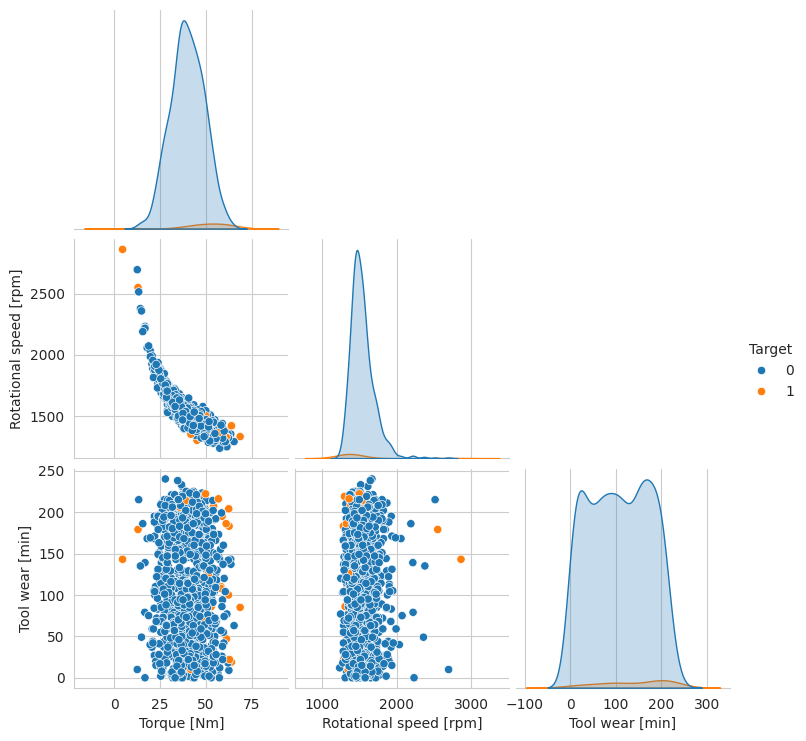

In [72]:
# 2.11 Pairplot for key features (sample for speed)

sample_df = df.sample(min(1000, len(df)), random_state=RANDOM_STATE)
sns.pairplot(
    sample_df[["Torque [Nm]", "Rotational speed [rpm]", "Tool wear [min]", "Target"]],
    hue="Target", corner=True, diag_kind="kde"
)
plt.show()

In [73]:
# 3.1 Feature engineering

def add_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    data["Temp_diff"] = data["Process temperature [K]"] - data["Air temperature [K]"]
    data["Power"] = data["Torque [Nm]"] * data["Rotational speed [rpm]"]
    data["Torque_per_rpm"] = data["Torque [Nm]"] / (data["Rotational speed [rpm]"] + 1e-6)
    data["Wear_torque"] = data["Tool wear [min]"] * data["Torque [Nm]"]
    data["Wear_rpm"] = data["Tool wear [min]"] * data["Rotational speed [rpm]"]
    data["Temp_ratio"] = data["Process temperature [K]"] / (data["Air temperature [K]"] + 1e-6)
    return data

df_fe = add_features(df)
display(df_fe.head())

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Temp_diff,Power,Torque_per_rpm,Wear_torque,Wear_rpm,Temp_ratio
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,10.5,66382.8,0.027595,0.0,0,1.035223
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,10.5,65190.4,0.032884,138.9,4224,1.035211
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,10.4,74001.2,0.032977,247.0,7490,1.034888
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,10.4,56603.5,0.027565,276.5,10031,1.034876
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,10.5,56320.0,0.028409,360.0,12672,1.035211


In [74]:
# 3.2 Define feature columns

target_col = "Target"
leak_col = "Failure Type"
drop_cols = ["UDI", "Product ID", target_col, leak_col]

features = [c for c in df_fe.columns if c not in drop_cols]
cat_features = ["Type"]
num_features = [c for c in features if c not in cat_features]

print("Categorical:", cat_features)
print("Numeric:", num_features)

Categorical: ['Type']
Numeric: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_diff', 'Power', 'Torque_per_rpm', 'Wear_torque', 'Wear_rpm', 'Temp_ratio']


In [75]:
# 3.3 Preprocessor

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

In [76]:
# 3.4 Stratified random split

X = df_fe[features]
y = df_fe[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train target ratio:", y_train.mean())
print("Test target ratio:", y_test.mean())

Train shape: (8000, 12) Test shape: (2000, 12)
Train target ratio: 0.033875
Test target ratio: 0.034


In [77]:
# 3.5 Chronological split by UDI

df_sorted = df_fe.sort_values("UDI").reset_index(drop=True)
split_idx = int(len(df_sorted) * 0.8)

train_chr = df_sorted.iloc[:split_idx]
test_chr = df_sorted.iloc[split_idx:]

X_train_chr = train_chr[features]
y_train_chr = train_chr[target_col]
X_test_chr = test_chr[features]
y_test_chr = test_chr[target_col]

print("Chronological train:", X_train_chr.shape, "test:", X_test_chr.shape)
print("Chronological train target ratio:", y_train_chr.mean())
print("Chronological test target ratio:", y_test_chr.mean())

Chronological train: (8000, 12) test: (2000, 12)
Chronological train target ratio: 0.0375
Chronological test target ratio: 0.0195


Target            1.000000
Torque_per_rpm    0.206493
Wear_torque       0.190427
Power             0.176039
Wear_rpm          0.085725
Temp_ratio       -0.111347
Temp_diff        -0.111676
Name: Target, dtype: float64

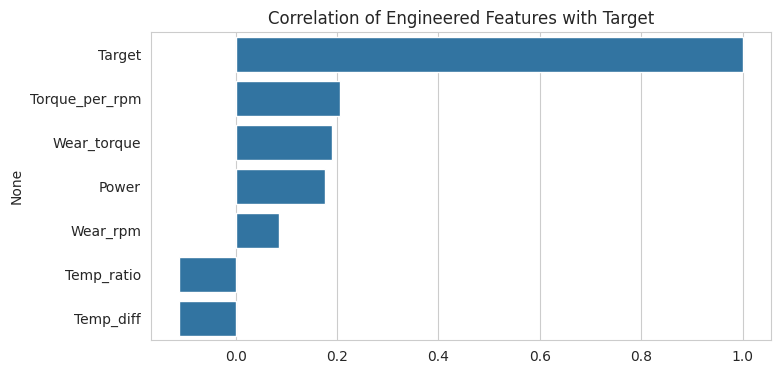

In [78]:
# 4.1 Correlation of engineered features with Target

engineered = ["Temp_diff", "Power", "Torque_per_rpm", "Wear_torque", "Wear_rpm", "Temp_ratio"]
corr_target = df_fe[engineered + ["Target"]].corr()["Target"].sort_values(ascending=False)
display(corr_target)

plt.figure(figsize=(8, 4))
sns.barplot(x=corr_target.values, y=corr_target.index)
plt.title("Correlation of Engineered Features with Target")
plt.show()

In [79]:
# 5.1 Business cost matrix

COST_FN = 10  # false negative cost
COST_FP = 1   # false positive cost

def expected_cost(y_true, y_prob, threshold, cost_fn=COST_FN, cost_fp=COST_FP):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return cost_fn * fn + cost_fp * fp

def tune_threshold(y_true, y_prob, cost_fn=COST_FN, cost_fp=COST_FP):
    thresholds = np.linspace(0.01, 0.99, 99)
    costs = [expected_cost(y_true, y_prob, t, cost_fn, cost_fp) for t in thresholds]
    best_idx = int(np.argmin(costs))
    return float(thresholds[best_idx]), float(costs[best_idx])

In [80]:
# 5.2 Imbalance strategies (resampling)

# Each resampler is compared on a Gradient Boosting model using CV on TRAINING data only.
# The resampler is applied inside each fold, so validation rows are never resampled.
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"Negative: {neg}, Positive: {pos}, scale_pos_weight: {scale_pos_weight:.2f}")

samplers = {
    "none": None,
    "smote": SMOTE(random_state=RANDOM_STATE),
    "adasyn": ADASYN(random_state=RANDOM_STATE),
    "ros": RandomOverSampler(random_state=RANDOM_STATE),
    "rus": RandomUnderSampler(random_state=RANDOM_STATE),
    "smoteenn": SMOTEENN(random_state=RANDOM_STATE),
    "smotetomek": SMOTETomek(random_state=RANDOM_STATE),
}

def build_pipe(clf, sampler_name="none"):
    """Preprocess -> optional resampler -> classifier. Resampling happens inside each CV fold only."""
    steps = [("prep", preprocessor)]
    if samplers[sampler_name] is not None:
        steps.append(("sampler", clone(samplers[sampler_name])))
    steps.append(("clf", clf))
    return ImbPipeline(steps=steps)

# Fixed Gradient Boosting settings for this comparison only (not the final tuned model)
sampler_probe = GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                           learning_rate=0.03, random_state=RANDOM_STATE)
sampler_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

sampler_rows = []
for s_name in samplers:
    scores = cross_validate(
        build_pipe(clone(sampler_probe), s_name),
        X_train, y_train, cv=sampler_cv,
        scoring=["average_precision", "roc_auc"], n_jobs=-1
    )
    sampler_rows.append({
        "Sampler": s_name,
        "CV PR-AUC": scores["test_average_precision"].mean(),
        "CV PR-AUC std": scores["test_average_precision"].std(),
        "CV ROC-AUC": scores["test_roc_auc"].mean(),
    })

sampler_df = (pd.DataFrame(sampler_rows)
              .sort_values("CV PR-AUC", ascending=False)
              .reset_index(drop=True))
display(sampler_df)

# Chosen by training-data CV only. Applied to every model in section 6.
BEST_SAMPLER = sampler_df.iloc[0]["Sampler"]
print("Resampler applied to all models in section 6:", BEST_SAMPLER)

Negative: 7729, Positive: 271, scale_pos_weight: 28.52


,Sampler,CV PR-AUC,CV PR-AUC std,CV ROC-AUC
0,none,0.914052,0.025501,0.981782
1,ros,0.899387,0.024761,0.981027
2,smote,0.881357,0.024392,0.980132
3,smotetomek,0.879986,0.023472,0.979902
4,adasyn,0.872526,0.020679,0.979020
5,smoteenn,0.796564,0.028886,0.975477
6,rus,0.723201,0.040147,0.976669


Resampler applied to all models in section 6: none


In [81]:
# 6.1 Model zoo and small hyperparameter grids

param_grids = {
    "logreg": {"clf__C": [0.01, 0.1, 1, 10]},
    "dt": {"clf__max_depth": [3, 5, 8, None], "clf__min_samples_leaf": [1, 5, 10]},
    "rf": {"clf__n_estimators": [200, 400], "clf__max_depth": [8, 12, None],
           "clf__min_samples_leaf": [1, 3, 5]},
    "et": {"clf__n_estimators": [200, 400], "clf__max_depth": [8, 12, None],
           "clf__min_samples_leaf": [1, 3, 5]},
    "gb": {"clf__n_estimators": [100, 200], "clf__learning_rate": [0.03, 0.05, 0.1],
           "clf__max_depth": [2, 3, 4]},
    "xgb": {"clf__n_estimators": [200, 400], "clf__learning_rate": [0.03, 0.05, 0.1],
            "clf__max_depth": [3, 4, 6], "clf__subsample": [0.7, 0.9, 1.0]},
    "cat": {"clf__iterations": [300, 600], "clf__learning_rate": [0.03, 0.05, 0.1],
            "clf__depth": [4, 6, 8]},
    "svm": {"clf__C": [0.1, 1, 10], "clf__gamma": ["scale", "auto"]},
    "knn": {"clf__n_neighbors": [3, 5, 11, 21], "clf__weights": ["uniform", "distance"]},
    "mlp": {"clf__hidden_layer_sizes": [(64,), (128,), (64, 32)],
            "clf__alpha": [0.0001, 0.001, 0.01]},
}

def get_model(name):
    if name == "dummy":
        return DummyClassifier(strategy="prior")
    if name == "logreg":
        return LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)
    if name == "dt":
        return DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)
    if name == "rf":
        return RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
    if name == "et":
        return ExtraTreesClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
    if name == "gb":
        return GradientBoostingClassifier(random_state=RANDOM_STATE)
    if name == "xgb":
        return XGBClassifier(
            random_state=RANDOM_STATE, eval_metric="logloss",
            scale_pos_weight=scale_pos_weight, n_jobs=-1
        )
    if name == "cat":
        return CatBoostClassifier(
            random_state=RANDOM_STATE, verbose=0,
            auto_class_weights="Balanced"
        )
    if name == "svm":
        return SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE)
    if name == "knn":
        return KNeighborsClassifier(n_jobs=-1)
    if name == "mlp":
        return MLPClassifier(max_iter=500, random_state=RANDOM_STATE)
    raise ValueError(name)

model_names = ["dummy", "logreg", "dt", "rf", "et", "gb", "xgb", "cat", "svm", "knn", "mlp"]

In [82]:
# 6.2 Training and evaluation loop 

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
trained_models = {}

for name in model_names:
    print(f"\nTraining {name} (resampler={BEST_SAMPLER})...")
    clf = get_model(name)
    pipe = build_pipe(clf, BEST_SAMPLER)

    if name in param_grids:
        search = RandomizedSearchCV(
            pipe, param_distributions=param_grids[name],
            n_iter=10, cv=cv, scoring="average_precision",
            random_state=RANDOM_STATE, n_jobs=-1, verbose=0
        )
        search.fit(X_train, y_train)
        best_pipe = search.best_estimator_
        best_params = search.best_params_
    else:
        best_pipe = pipe.fit(X_train, y_train)
        best_params = {}

    # CV PR-AUC (note: hyperparameters were chosen on these same folds, so this is mildly optimistic)
    cv_scores = cross_validate(
        clone(best_pipe), X_train, y_train, cv=cv,
        scoring=["average_precision", "roc_auc"], n_jobs=-1
    )

    # 1) Threshold from out-of-fold predictions on TRAINING data only
    oof_prob = cross_val_predict(
        clone(best_pipe), X_train, y_train,
        cv=cv, method="predict_proba", n_jobs=-1
    )[:, 1]
    threshold, oof_cost = tune_threshold(y_train, oof_prob)

    # 2) Apply the fixed threshold to the test set once
    y_prob = best_pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    cost = expected_cost(y_test, y_prob, threshold)

    metrics = {
        "Model": name,
        "Best Params": best_params,
        "CV PR-AUC": cv_scores["test_average_precision"].mean(),
        "CV ROC-AUC": cv_scores["test_roc_auc"].mean(),
        "Test PR-AUC": average_precision_score(y_test, y_prob),
        "Test ROC-AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "Balanced Acc": balanced_accuracy_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "Brier": brier_score_loss(y_test, y_prob),
        "Threshold": threshold,
        "Threshold At Edge": bool(threshold <= 0.01 or threshold >= 0.99),
        "OOF Cost (train)": oof_cost,
        "Expected Cost": cost,
    }
    results.append(metrics)
    trained_models[name] = best_pipe

# Rank by CV PR-AUC (training data), not test PR-AUC
results_df = pd.DataFrame(results).sort_values(
    by=["CV PR-AUC", "Expected Cost"], ascending=[False, True]
).reset_index(drop=True)
display(results_df)


Training dummy (resampler=none)...

Training logreg (resampler=none)...

Training dt (resampler=none)...

Training rf (resampler=none)...

Training et (resampler=none)...

Training gb (resampler=none)...

Training xgb (resampler=none)...

Training cat (resampler=none)...

Training svm (resampler=none)...

Training knn (resampler=none)...

Training mlp (resampler=none)...


,Model,Best Params,CV PR-AUC,CV ROC-AUC,Test PR-AUC,Test ROC-AUC,Precision,Recall,F1,Balanced Acc,MCC,Brier,Threshold,Threshold At Edge,OOF Cost (train),Expected Cost
0,gb,"{'clf__n_estimators': 200, 'clf__max_depth': 3...",0.914052,0.981782,0.904502,0.973473,0.950000,0.838235,0.890625,0.918341,0.888878,0.006586,0.28,False,434.0,113
1,rf,"{'clf__n_estimators': 400, 'clf__min_samples_l...",0.888361,0.976384,0.882276,0.980095,0.918033,0.823529,0.868217,0.910471,0.865200,0.008973,0.28,False,472.0,125
2,cat,"{'clf__learning_rate': 0.05, 'clf__iterations'...",0.875564,0.977788,0.867240,0.980582,0.614583,0.867647,0.719512,0.924248,0.719347,0.009521,0.15,False,469.0,127
3,xgb,"{'clf__subsample': 1.0, 'clf__n_estimators': 2...",0.873485,0.978473,0.885378,0.981762,0.600000,0.838235,0.699387,0.909283,0.697433,0.010835,0.24,False,489.0,148
4,dt,"{'clf__min_samples_leaf': 10, 'clf__max_depth'...",0.842943,0.950526,0.822447,0.922037,0.670588,0.838235,0.745098,0.911871,0.740041,0.037655,0.73,False,534.0,138
5,et,"{'clf__n_estimators': 400, 'clf__min_samples_l...",0.823077,0.968450,0.831959,0.973835,0.479339,0.852941,0.613757,0.910166,0.623580,0.013129,0.13,False,654.0,163
6,mlp,"{'clf__hidden_layer_sizes': (64, 32), 'clf__al...",0.791822,0.968277,0.831285,0.983741,0.526786,0.867647,0.655556,0.920107,0.662275,0.012651,0.19,False,692.0,143
7,svm,"{'clf__gamma': 'auto', 'clf__C': 0.1}",0.681704,0.963180,0.659595,0.970223,0.453782,0.794118,0.577540,0.880237,0.582605,0.018261,0.21,False,757.0,205
8,knn,"{'clf__weights': 'distance', 'clf__n_neighbors...",0.661482,0.931049,0.669496,0.940560,0.410853,0.779412,0.538071,0.870037,0.546011,0.019698,0.12,False,869.0,226
9,logreg,{'clf__C': 0.01},0.468413,0.909516,0.421416,0.924172,0.340580,0.691176,0.456311,0.822038,0.460538,0.114632,0.72,False,1427.0,301


Best model: gb
Best threshold: 0.28

Classification Report:
              precision    recall  f1-score   support

           0     0.9943    0.9984    0.9964      1932
           1     0.9500    0.8382    0.8906        68

    accuracy                         0.9930      2000
   macro avg     0.9722    0.9183    0.9435      2000
weighted avg     0.9928    0.9930    0.9928      2000



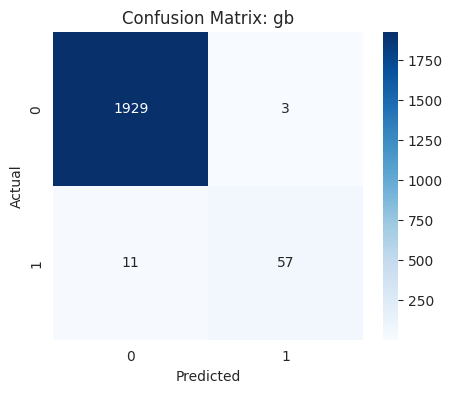

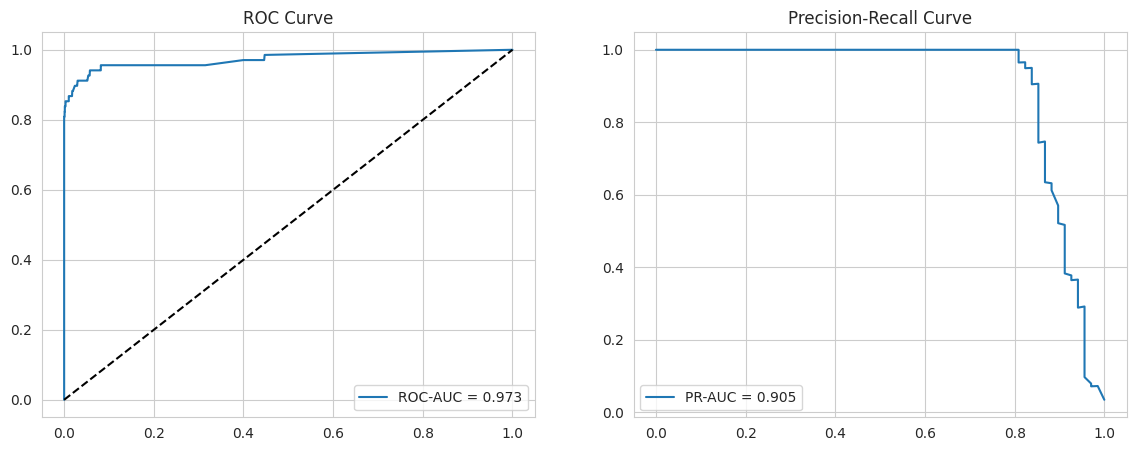

In [83]:
# 7.1 Best model detailed evaluation

best_model_name = results_df.iloc[0]["Model"]
best_pipe = trained_models[best_model_name]
best_threshold = results_df.iloc[0]["Threshold"]

print("Best model:", best_model_name)
print("Best threshold:", best_threshold)

y_prob_best = best_pipe.predict_proba(X_test)[:, 1]
y_pred_best = (y_prob_best >= best_threshold).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, digits=4))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

# ROC and PR curves
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
prec, rec, _ = precision_recall_curve(y_test, y_prob_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_prob_best):.3f}")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_title("ROC Curve")
axes[0].legend()

axes[1].plot(rec, prec, label=f"PR-AUC = {average_precision_score(y_test, y_prob_best):.3f}")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()
plt.show()

In [84]:
# 7.2 Chronological validation of best model 

best_pipe_chr = clone(best_pipe)
best_pipe_chr.fit(X_train_chr, y_train_chr)

chr_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_chr = cross_val_predict(
    clone(best_pipe), X_train_chr, y_train_chr,
    cv=chr_cv, method="predict_proba", n_jobs=-1
)[:, 1]
threshold_chr, oof_cost_chr = tune_threshold(y_train_chr, oof_chr)

y_prob_chr = best_pipe_chr.predict_proba(X_test_chr)[:, 1]
y_pred_chr = (y_prob_chr >= threshold_chr).astype(int)
cost_chr = expected_cost(y_test_chr, y_prob_chr, threshold_chr)

print("Chronological validation (threshold from training window):")
print("Threshold:", round(threshold_chr, 2))
print("PR-AUC:", average_precision_score(y_test_chr, y_prob_chr))
print("ROC-AUC:", roc_auc_score(y_test_chr, y_prob_chr))
print("Recall:", recall_score(y_test_chr, y_pred_chr, zero_division=0))
print("Precision:", precision_score(y_test_chr, y_pred_chr, zero_division=0))
print("Expected Cost:", cost_chr)
print(classification_report(y_test_chr, y_pred_chr, digits=4))

Chronological validation (threshold from training window):
Threshold: 0.05
PR-AUC: 0.8209826083936663
ROC-AUC: 0.9720903777507551
Recall: 0.7948717948717948
Precision: 0.5166666666666667
Expected Cost: 109
              precision    recall  f1-score   support

           0     0.9959    0.9852    0.9905      1961
           1     0.5167    0.7949    0.6263        39

    accuracy                         0.9815      2000
   macro avg     0.7563    0.8900    0.8084      2000
weighted avg     0.9865    0.9815    0.9834      2000



In [85]:
# 8.1 Final comparison table (ranked by training-data CV, test shown for reporting)

comparison = results_df[[
    "Model", "Best Params", "CV PR-AUC", "CV ROC-AUC", "Test PR-AUC",
    "Recall", "Precision", "F1", "Expected Cost", "Threshold", "Threshold At Edge"
]].copy()
comparison = comparison.sort_values(["CV PR-AUC", "Expected Cost"], ascending=[False, True])
display(comparison)

,Model,Best Params,CV PR-AUC,CV ROC-AUC,Test PR-AUC,Recall,Precision,F1,Expected Cost,Threshold,Threshold At Edge
0,gb,"{'clf__n_estimators': 200, 'clf__max_depth': 3...",0.914052,0.981782,0.904502,0.838235,0.950000,0.890625,113,0.28,False
1,rf,"{'clf__n_estimators': 400, 'clf__min_samples_l...",0.888361,0.976384,0.882276,0.823529,0.918033,0.868217,125,0.28,False
2,cat,"{'clf__learning_rate': 0.05, 'clf__iterations'...",0.875564,0.977788,0.867240,0.867647,0.614583,0.719512,127,0.15,False
3,xgb,"{'clf__subsample': 1.0, 'clf__n_estimators': 2...",0.873485,0.978473,0.885378,0.838235,0.600000,0.699387,148,0.24,False
4,dt,"{'clf__min_samples_leaf': 10, 'clf__max_depth'...",0.842943,0.950526,0.822447,0.838235,0.670588,0.745098,138,0.73,False
5,et,"{'clf__n_estimators': 400, 'clf__min_samples_l...",0.823077,0.968450,0.831959,0.852941,0.479339,0.613757,163,0.13,False
6,mlp,"{'clf__hidden_layer_sizes': (64, 32), 'clf__al...",0.791822,0.968277,0.831285,0.867647,0.526786,0.655556,143,0.19,False
7,svm,"{'clf__gamma': 'auto', 'clf__C': 0.1}",0.681704,0.963180,0.659595,0.794118,0.453782,0.577540,205,0.21,False
8,knn,"{'clf__weights': 'distance', 'clf__n_neighbors...",0.661482,0.931049,0.669496,0.779412,0.410853,0.538071,226,0.12,False
9,logreg,{'clf__C': 0.01},0.468413,0.909516,0.421416,0.691176,0.340580,0.456311,301,0.72,False


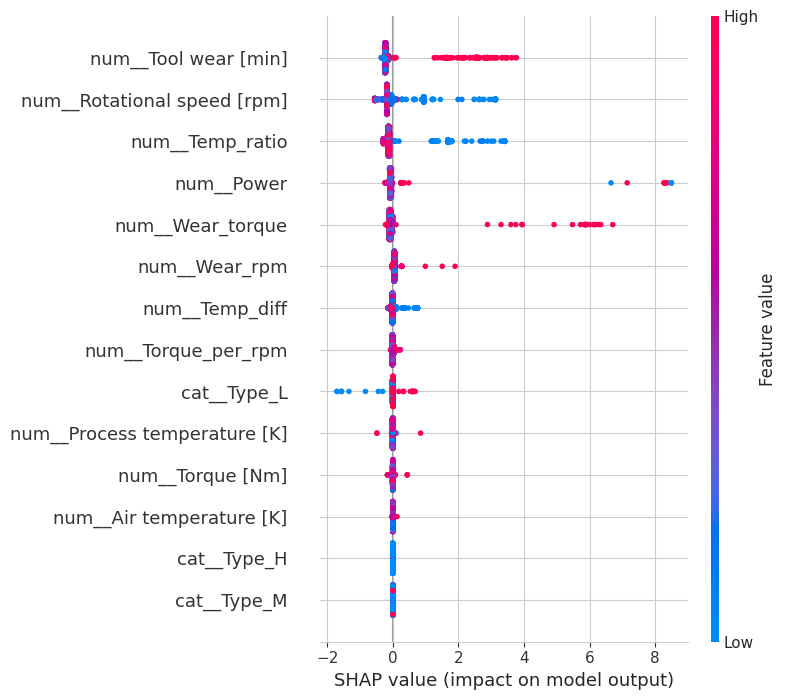

In [86]:
# 9.1 SHAP for best tree model

prep = best_pipe.named_steps["prep"]
clf = best_pipe.named_steps["clf"]

X_test_trans = prep.transform(X_test)
feature_names = prep.get_feature_names_out()

# Use TreeExplainer if tree-based, otherwise KernelExplainer on a sample
try:
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_test_trans)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    shap.summary_plot(shap_values, X_test_trans, feature_names=feature_names, show=True)
except Exception as e:
    print("TreeExplainer failed, using KernelExplainer on sample:", e)
    sample = X_test_trans[:100]
    explainer = shap.KernelExplainer(clf.predict_proba, sample)
    shap_values = explainer.shap_values(sample)
    shap.summary_plot(shap_values[1], sample, feature_names=feature_names)

Top SHAP features: ['num__Tool wear [min]', 'num__Rotational speed [rpm]', 'num__Temp_ratio', 'num__Power', 'num__Wear_torque']


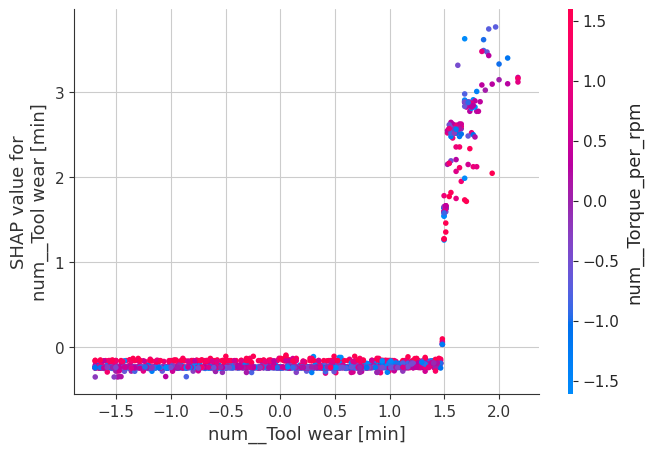

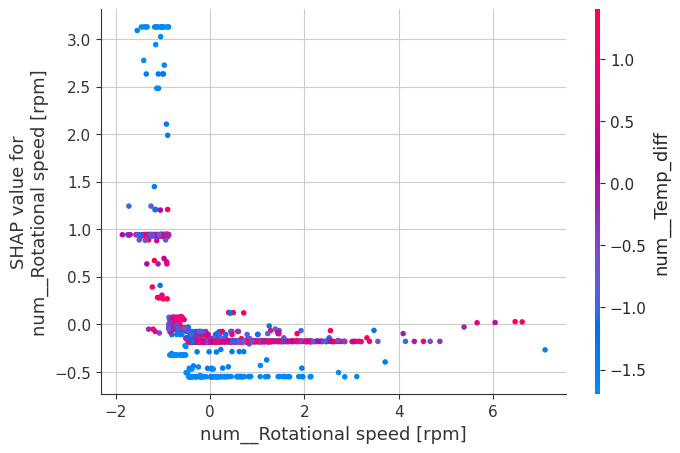

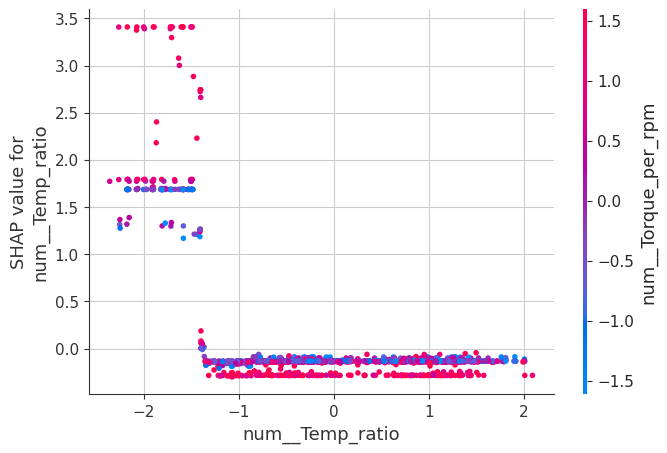

In [87]:
# 9.2 SHAP dependence plots for top features

mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[-5:][::-1]
top_features = [feature_names[i] for i in top_idx]
print("Top SHAP features:", top_features)

for feat in top_features[:3]:
    idx = list(feature_names).index(feat)
    shap.dependence_plot(idx, shap_values, X_test_trans, feature_names=feature_names, show=True)

,Feature,Importance,Std
7,Power,0.339368,0.026667
3,Rotational speed [rpm],0.326751,0.019048
11,Temp_ratio,0.270608,0.017300
9,Wear_torque,0.217520,0.021906
5,Tool wear [min],0.074198,0.006911
0,Type,0.038984,0.018084
10,Wear_rpm,0.005699,0.003877
6,Temp_diff,0.004512,0.002136
4,Torque [Nm],0.000537,0.000093
8,Torque_per_rpm,0.000124,0.001812


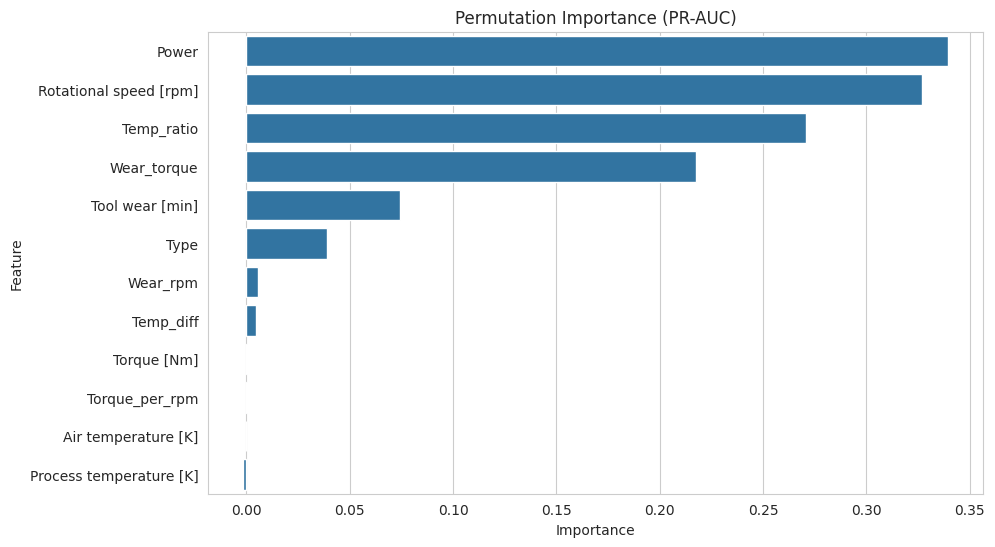

In [88]:
# 9.3 Permutation importance

perm = permutation_importance(
    best_pipe, X_test, y_test, n_repeats=10,
    random_state=RANDOM_STATE, scoring="average_precision", n_jobs=-1
)
perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean,
    "Std": perm.importances_std
}).sort_values("Importance", ascending=False)

display(perm_df.head(15))
sns.barplot(data=perm_df.head(15), x="Importance", y="Feature")
plt.title("Permutation Importance (PR-AUC)")
plt.show()

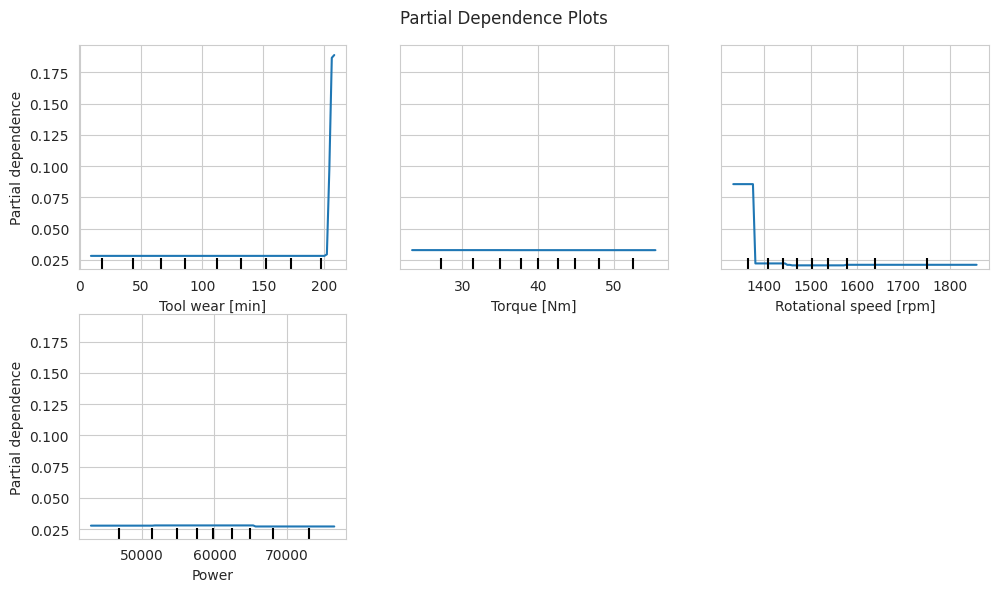

In [89]:
# 9.4 Partial dependence plots

top_raw_features = [f for f in ["Tool wear [min]", "Torque [Nm]", "Rotational speed [rpm]",
                                "Power", "Wear_torque"] if f in X_test.columns]
PartialDependenceDisplay.from_estimator(
    best_pipe, X_test, features=top_raw_features[:4], kind="average"
)
plt.suptitle("Partial Dependence Plots")
plt.tight_layout()
plt.show()

In [90]:
# 10.1 Save best model

best_model_path = "best_predictive_maintenance_model.joblib"
joblib.dump({
    "model": best_pipe,
    "threshold": best_threshold,
    "features": features,
    "cat_features": cat_features,
    "num_features": num_features,
    "model_name": best_model_name,
    "resampler": BEST_SAMPLER,
    "cost_fn": COST_FN,
    "cost_fp": COST_FP,
    "metrics": results_df.iloc[0].to_dict()
}, best_model_path)

print("Saved:", best_model_path)

Saved: best_predictive_maintenance_model.joblib


In [91]:
# 10.2 Inference function (with input validation)

REQUIRED_COLS = [
    "Type", "Air temperature [K]", "Process temperature [K]",
    "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"
]
NUMERIC_COLS = [c for c in REQUIRED_COLS if c != "Type"]
VALID_TYPES = {"L", "M", "H"}

def validate_input(input_dict):
    missing = set(REQUIRED_COLS) - set(input_dict.keys())
    if missing:
        raise ValueError(f"Missing required fields: {sorted(missing)}")
    if input_dict["Type"] not in VALID_TYPES:
        raise ValueError(f"Type must be one of {sorted(VALID_TYPES)}, got {input_dict['Type']!r}")
    clean = {"Type": input_dict["Type"]}
    for c in NUMERIC_COLS:
        try:
            v = float(input_dict[c])
        except (TypeError, ValueError):
            raise ValueError(f"{c} must be numeric, got {input_dict[c]!r}")
        if not np.isfinite(v):
            raise ValueError(f"{c} must be finite")
        clean[c] = v
    if clean["Rotational speed [rpm]"] <= 0:
        raise ValueError("Rotational speed [rpm] must be positive")
    return clean

def predict_failure(input_dict, model_path=best_model_path):
    artifact = joblib.load(model_path)
    model = artifact["model"]
    threshold = artifact["threshold"]

    clean = validate_input(input_dict)
    row = add_features(pd.DataFrame([clean]))
    prob = float(model.predict_proba(row[artifact["features"]])[0, 1])
    pred = int(prob >= threshold)

    return {
        "failure_probability": prob,
        "failure_prediction": pred,
        "threshold": threshold,
        "model_name": artifact["model_name"],
        "resampler": artifact.get("resampler", "none"),
    }

# 10.3 Example inference
example = {
    "Type": "L",
    "Air temperature [K]": 298.1,
    "Process temperature [K]": 308.6,
    "Rotational speed [rpm]": 1551,
    "Torque [Nm]": 42.8,
    "Tool wear [min]": 0
}
print(predict_failure(example))

{'failure_probability': 0.002452063740621312, 'failure_prediction': 0, 'threshold': np.float64(0.28), 'model_name': 'gb', 'resampler': 'none'}


Dropped label-conflict rows: 27
Class counts after cleaning:
Failure Type
No Failure                  9643
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Name: count, dtype: int64
Macro F1: 0.7505

Classification Report:
                          precision    recall  f1-score   support

Heat Dissipation Failure     1.0000    1.0000    1.0000        22
              No Failure     0.9948    0.9974    0.9961      1929
      Overstrain Failure     0.8421    1.0000    0.9143        16
           Power Failure     0.8421    0.8421    0.8421        19
       Tool Wear Failure     0.0000    0.0000    0.0000         9

                accuracy                         0.9915      1995
               macro avg     0.7358    0.7679    0.7505      1995
            weighted avg     0.9877    0.9915    0.9895      1995



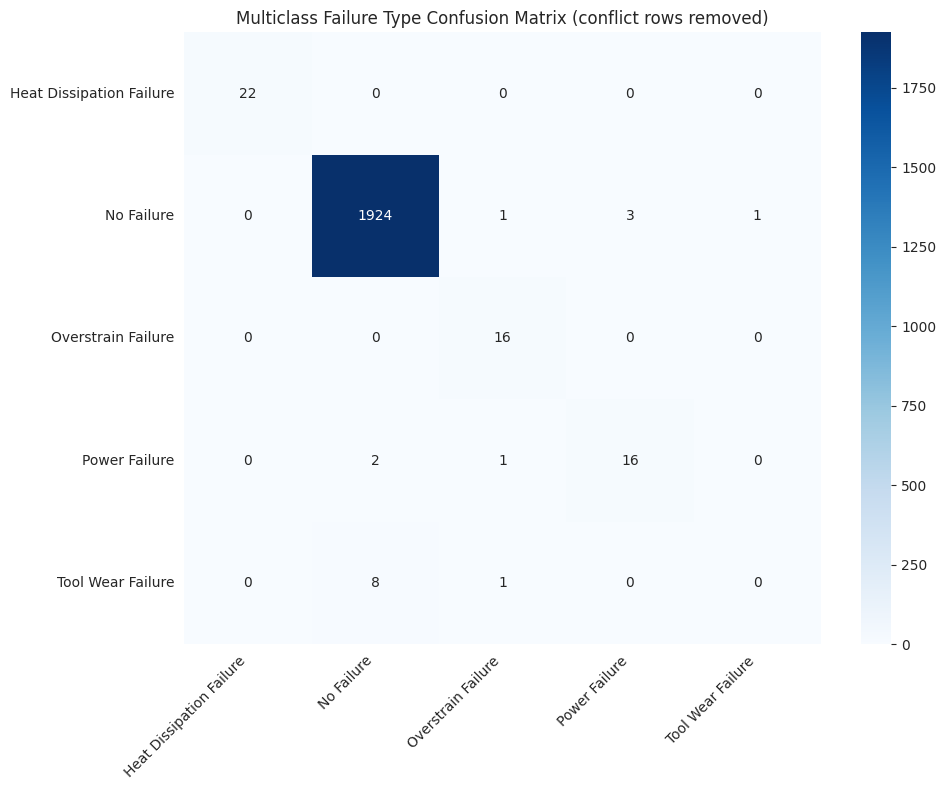

In [92]:
# 11.1 Multiclass Failure Type (corrected)

df_mc = add_features(df).copy()

conflict = (
    ((df_mc["Target"] == 1) & (df_mc["Failure Type"] == "No Failure")) |
    ((df_mc["Target"] == 0) & (df_mc["Failure Type"] != "No Failure"))
)
print("Dropped label-conflict rows:", int(conflict.sum()))
df_mc = df_mc[~conflict].copy()

X_mc = df_mc[features]
y_mc = df_mc["Failure Type"]
print("Class counts after cleaning:")
print(y_mc.value_counts())

X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, stratify=y_mc, random_state=RANDOM_STATE
)

mc_model = ImbPipeline(steps=[
    ("prep", preprocessor),
    ("clf", LGBMClassifier(
        random_state=RANDOM_STATE, class_weight="balanced",
        n_jobs=-1, verbose=-1
    ))
])

mc_model.fit(X_train_mc, y_train_mc)
y_pred_mc = mc_model.predict(X_test_mc)

print("Macro F1:", round(f1_score(y_test_mc, y_pred_mc, average="macro"), 4))
print("\nClassification Report:")
print(classification_report(y_test_mc, y_pred_mc, digits=4, zero_division=0))

cm_mc = confusion_matrix(y_test_mc, y_pred_mc, labels=mc_model.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_mc, annot=True, fmt="d", cmap="Blues",
            xticklabels=mc_model.classes_, yticklabels=mc_model.classes_)
plt.title("Multiclass Failure Type Confusion Matrix (conflict rows removed)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()